<span style = "font-family: Verdana; font-size: 20px">

#### **Feature Engineering**
</span>

In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split  

from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

from sklearn.feature_selection import RFE
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

In [73]:
df = pd.read_csv("pokemon/data/modified/viz_pokemon.csv", keep_default_na = False)
combats_df = pd.read_csv('pokemon/data/raw_data/combats.csv')
combats_df = combats_df.drop_duplicates().reset_index(drop=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 54 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  800 non-null    int64  
 1   Name                800 non-null    object 
 2   Type1               800 non-null    object 
 3   Type2               800 non-null    object 
 4   HiddenAbility       800 non-null    object 
 5   Generation          800 non-null    int64  
 6   Hp                  800 non-null    float64
 7   Attack              800 non-null    float64
 8   Defense             800 non-null    float64
 9   SpecialAttack       800 non-null    float64
 10  SpecialDefense      800 non-null    float64
 11  Speed               800 non-null    float64
 12  TotalStats          800 non-null    float64
 13  Weight              800 non-null    float64
 14  Height              800 non-null    float64
 15  GenderProbM         800 non-null    float64
 16  Category

Dummify cột `Type1` và `Type2`

In [74]:
type1dum = pd.get_dummies(df['Type1'], prefix='Type', dtype=int)
type2dum = pd.get_dummies(df['Type2'], prefix='Type', dtype=int)

dummies_total = type1dum.add(type2dum, fill_value=0)
df = pd.concat([df, dummies_total], axis=1)
df = df.drop(['Type1', 'Type2'], axis=1)

Chuyển `LevelingRate` thành các giá trị số tương ứng để sử dụng trong mô hình ML.

[Nguồn tham khảo](https://bulbapedia.bulbagarden.net/wiki/Experience)


In [75]:
df['LevelingRate'] = df['LevelingRate'].replace(['Slow', 'Medium Slow', 'Medium Fast', 'Fast', 'Erratic', 'Fluctuating'], [1250000, 1059860, 1000000, 800000, 600000, 1640000]).infer_objects(copy=False)

C:\Users\HP\AppData\Local\Temp\ipykernel_14676\1293140977.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['LevelingRate'] = df['LevelingRate'].replace(['Slow', 'Medium Slow', 'Medium Fast', 'Fast', 'Erratic', 'Fluctuating'], [1250000, 1059860, 1000000, 800000, 600000, 1640000]).infer_objects(copy=False)


In [76]:
def create_intrinsic_metrics(df):
    # --- Alpha Strike (Sức Tấn Công Tối Ưu) ---
    df['Alpha_Strike'] = df[['Attack', 'SpecialAttack']].max(axis=1)

    # --- Durability Score (Khả Năng Chịu Đựng) ---
    df['Durability_Score'] = (df['Hp'] * (df['Defense'] + df['SpecialDefense'])) / 100

    # --- Sweeper Rating (Chỉ Số Quét Team) ---
    df['Sweeper_Rating'] = (df['Speed'] * df['Alpha_Strike']) / 1000

    # --- Glass Cannon Index (Chỉ Số "Máu Giấy") ---
    df['Glass_Cannon_Index'] = df['Alpha_Strike'] / (df['Defense'] + df['SpecialDefense'] + 1)

    # --- Type Vulnerability (Tổng Mức Độ Bị Khắc Chế) ---
    dmg_cols = [c for c in df.columns if c.startswith('DamageFrom')]
    df['Type_Vulnerability'] = df[dmg_cols].apply(lambda row: sum(x for x in row if x > 1.0), axis=1)
    
    cols_to_drop_safe = [col for col in df.columns if col.startswith('DamageFrom')]
    df.drop(columns=cols_to_drop_safe, inplace=True)

    return df

df = create_intrinsic_metrics(df)

**Xoá bỏ các cột chứa thông tin không giúp ích cho việc dự đoán kết quả chiến thắng của Pokemon. Các cột được loại bỏ liên quan đến các thông tin sơ bộ về Pokemon (chỉ số nội tại), thông tin có thể gây leakage**

In [77]:
drop_cols = [
    'PreevoName', 'FightsWon', 'TotalFights', 'WinPercentage', 'HasMega', 'NoGender',
    'Weight', 'Height', 'GenderProbM', 'Category', 'EggCycles', 'BaseFriendship',
    'EggGroup1', 'EggGroup2'
]
df.drop(columns = drop_cols, inplace = True)

In [78]:
pd.set_option('display.max_columns', None)
df.head()

,ID,Name,HiddenAbility,Generation,Hp,Attack,Defense,SpecialAttack,SpecialDefense,Speed,TotalStats,CatchRate,LevelingRate,IsLegendary,IsMythical,EvoStage,TotalEvoStages,Ability1,Ability2,IsMega,Type_Bug,Type_Dark,Type_Dragon,Type_Electric,Type_Fairy,Type_Fighting,Type_Fire,Type_Flying,Type_Ghost,Type_Grass,Type_Ground,Type_Ice,Type_Normal,Type_Poison,Type_Psychic,Type_Rock,Type_Steel,Type_Water,Alpha_Strike,Durability_Score,Sweeper_Rating,Glass_Cannon_Index,Type_Vulnerability
0,1,Bulbasaur,Chlorophyll,1,45.0,49.0,49.0,65.0,65.0,45.0,318.0,45,1059860,0,0,1,3,Overgrow,None,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,65.0,51.30,2.925,0.565217,8.0
1,2,Ivysaur,Chlorophyll,1,60.0,62.0,63.0,80.0,80.0,60.0,405.0,45,1059860,0,0,2,3,Overgrow,None,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,80.0,85.80,4.800,0.555556,8.0
2,3,Venusaur,Chlorophyll,1,80.0,82.0,83.0,100.0,100.0,80.0,525.0,45,1059860,0,0,3,3,Overgrow,None,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,100.0,146.40,8.000,0.543478,8.0
3,4,Mega Venusaur,None,1,80.0,100.0,123.0,122.0,120.0,80.0,625.0,45,1059860,0,0,3,3,Thick Fat,None,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,122.0,194.40,9.760,0.500000,4.0
4,5,Charmander,Solar Power,1,39.0,52.0,43.0,60.0,50.0,65.0,309.0,45,1059860,0,0,1,3,Blaze,None,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,60.0,36.27,3.900,0.638298,6.0


**Merge dữ liệu từ hai tập Pokemon và Combats.csv để có bộ dữ liệu đầy đủ thông tin về dự đoán kết quả trận đấu**

In [79]:
stats_p1 = df.add_suffix('_P1')
stats_p2 = df.add_suffix('_P2')

# Merge cho Pokemon thứ nhất (First_pokemon)
final_df = pd.merge(
    combats_df,
    stats_p1,
    left_on='First_pokemon', 
    right_on='ID_P1',
    how='inner'
)

# Merge cho Pokemon thứ hai (Second_pokemon)
final_df = pd.merge(
    final_df,
    stats_p2,
    left_on='Second_pokemon', 
    right_on='ID_P2',
    how='inner'
)

# Tạo biến mục tiêu (P1 thắng = 1)
final_df['P1_Win'] = (final_df['Winner'] == final_df['First_pokemon']).astype(int)

final_df = final_df.drop(columns=['ID_P1', 'ID_P2', 'Winner', 'First_pokemon', 'Second_pokemon', 'Name_P1', 'Name_P2'])

In [80]:
final_df.shape

(48048, 83)

In [81]:
final_df.head()

,HiddenAbility_P1,Generation_P1,Hp_P1,Attack_P1,Defense_P1,SpecialAttack_P1,SpecialDefense_P1,Speed_P1,TotalStats_P1,CatchRate_P1,LevelingRate_P1,IsLegendary_P1,IsMythical_P1,EvoStage_P1,TotalEvoStages_P1,Ability1_P1,Ability2_P1,IsMega_P1,Type_Bug_P1,Type_Dark_P1,Type_Dragon_P1,Type_Electric_P1,Type_Fairy_P1,Type_Fighting_P1,Type_Fire_P1,Type_Flying_P1,Type_Ghost_P1,Type_Grass_P1,Type_Ground_P1,Type_Ice_P1,Type_Normal_P1,Type_Poison_P1,Type_Psychic_P1,Type_Rock_P1,Type_Steel_P1,Type_Water_P1,Alpha_Strike_P1,Durability_Score_P1,Sweeper_Rating_P1,Glass_Cannon_Index_P1,Type_Vulnerability_P1,HiddenAbility_P2,Generation_P2,Hp_P2,Attack_P2,Defense_P2,SpecialAttack_P2,SpecialDefense_P2,Speed_P2,TotalStats_P2,CatchRate_P2,LevelingRate_P2,IsLegendary_P2,IsMythical_P2,EvoStage_P2,TotalEvoStages_P2,Ability1_P2,Ability2_P2,IsMega_P2,Type_Bug_P2,Type_Dark_P2,Type_Dragon_P2,Type_Electric_P2,Type_Fairy_P2,Type_Fighting_P2,Type_Fire_P2,Type_Flying_P2,Type_Ghost_P2,Type_Grass_P2,Type_Ground_P2,Type_Ice_P2,Type_Normal_P2,Type_Poison_P2,Type_Psychic_P2,Type_Rock_P2,Type_Steel_P2,Type_Water_P2,Alpha_Strike_P2,Durability_Score_P2,Sweeper_Rating_P2,Glass_Cannon_Index_P2,Type_Vulnerability_P2,P1_Win
0,Sand Veil,2,50.0,64.0,50.0,45.0,50.0,41.0,300.0,45,1250000,0,0,1,3,Guts,None,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,64.0,50.00,2.624,0.633663,16.0,Pickpocket,3,70.0,70.0,40.0,60.0,40.0,60.0,340.0,120,1059860,0,0,2,3,Chlorophyll,Early Bird,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,70.0,56.0,4.200,0.864198,16.0,0
1,None,5,91.0,90.0,72.0,90.0,129.0,108.0,580.0,3,1250000,1,0,1,1,Justified,None,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,90.0,182.91,9.720,0.445545,14.0,None,5,91.0,129.0,90.0,72.0,90.0,108.0,580.0,3,1250000,1,0,1,1,Justified,None,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,129.0,163.8,13.932,0.712707,14.0,0
2,Super Luck,2,55.0,40.0,85.0,80.0,105.0,40.0,405.0,75,800000,0,0,2,3,Hustle,Serene Grace,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,80.0,104.50,3.200,0.418848,10.0,Analytic,5,75.0,75.0,75.0,125.0,95.0,40.0,485.0,90,1000000,0,0,2,2,Telepathy,Synchronize,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,125.0,127.5,5.000,0.730994,6.0,0
3,Weak Armor,2,40.0,40.0,40.0,70.0,40.0,20.0,250.0,190,1000000,0,0,1,2,Magma Armor,Flame Body,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,70.0,32.00,1.400,0.864198,6.0,Mold Breaker,5,77.0,120.0,90.0,60.0,90.0,48.0,485.0,45,1000000,0,0,1,1,Rough Skin,Sheer Force,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,120.0,138.6,5.760,0.662983,6.0,0
4,Weak Armor,1,70.0,60.0,125.0,115.0,70.0,55.0,495.0,45,1000000,0,0,2,2,Swift Swim,Shell Armor,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,115.0,136.50,6.325,0.586735,10.0,Contrary,2,20.0,10.0,230.0,10.0,230.0,5.0,505.0,190,1059860,0,0,1,1,Sturdy,Gluttony,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,10.0,92.0,0.050,0.021692,6.0,1


### **Feature Engineering tạo các biến tương quan giữa Pokemon thứ nhất và thứ hai**

In [82]:
def create_feature(df):
    # Tấn công Vật lý vs Phòng thủ Vật lý (Physical Matchup)
    df['Phys_Advantage_P1'] = df['Attack_P1'] / (df['Defense_P2']+ 0.1)
    df['Phys_Advantage_P2'] = df['Attack_P2'] / (df['Defense_P1']+ 0.1)

    # Tấn công Đặc biệt vs Phòng thủ Đặc biệt (Special Matchup)
    df['Spec_Advantage_P1'] = df['SpecialAttack_P1'] / (df['SpecialDefense_P2'] + 0.1)
    df['Spec_Advantage_P2'] = df['SpecialAttack_P2'] / (df['SpecialDefense_P1'] + 0.1)

    # Alpha Strike: Khả năng dồn dame nhanh
    df['Alpha_Diff'] = df['Alpha_Strike_P1'] - df['Alpha_Strike_P2']
    
    df['Physical_Power_P1'] = df['Attack_P1'] * df['Speed_P1']

    df['Special_Power_P1'] = df['SpecialAttack_P1'] * df['Speed_P1']

    df['Log_Att_Def_Diff'] = np.log(df['Attack_P1'] + 1) - np.log(df['Defense_P2'] + 1)

    return df

In [83]:
# SPEED-BASED FEATURES =========================================

def add_speed_features(df):
    df['Speed_Difference'] = df['Speed_P1'] - df['Speed_P2']
    df['Speed_Ratio'] = df['Speed_P1'] / (df['Speed_P2'] + 1)
    
    df['Is_P1_Faster'] = (df['Speed_P1'] > df['Speed_P2']).astype(int)
    
    df['Speed_Tie'] = ((df['Speed_Ratio'] > 0.95) & (df['Speed_Ratio'] < 1.05)).astype(int)
    
    return df

In [84]:
# DEFENSIVE CAPABILITIES ==========================================

def add_defensive_features(df):
    df['P1_Physical_Bulk'] = df['Hp_P1'] * df['Defense_P1']
    df['P2_Physical_Bulk'] = df['Hp_P2'] * df['Defense_P2']
    
    df['P1_Special_Bulk'] = df['Hp_P1'] * df['SpecialDefense_P1']
    df['P2_Special_Bulk'] = df['Hp_P2'] * df['SpecialDefense_P2']
    
    df['P1_Overall_Bulk'] = (df['P1_Physical_Bulk'] + df['P1_Special_Bulk']) / 2
    df['P2_Overall_Bulk'] = (df['P2_Physical_Bulk'] + df['P2_Special_Bulk']) / 2
    
    df['Bulk_Advantage_P1'] = df['P1_Overall_Bulk'] / (df['P2_Overall_Bulk'] + 1)
    
    return df

In [85]:
def diff_features(df):    
    stats_cols = [
        'Hp', 'Defense', 'SpecialAttack', 'TotalStats',
        'SpecialDefense', 'Attack'
    ]

    for col in stats_cols:
        df[f'Diff_{col}'] = df[f'{col}_P1'] - df[f'{col}_P2']

        df.drop(columns=[f'{col}_P1', f'{col}_P2'], inplace=True)

    special_flags = ['IsLegendary', 'IsMythical']
    for col in special_flags:
        df[f'Diff_{col}'] = df[f'{col}_P1'] - df[f'{col}_P2']
        df.drop(columns=[f'{col}_P1', f'{col}_P2'], inplace=True)
    
    return df

In [86]:
def engineer_all_features(df):
    """Apply all feature engineering steps"""
    df = create_feature(df)
    df = add_speed_features(df)
    df = add_defensive_features(df)
    df = diff_features(df)
    
    return df

pokemon_df = engineer_all_features(final_df)

In [87]:
pd.set_option('display.max_columns', None)
pokemon_df.head()

,HiddenAbility_P1,Generation_P1,Speed_P1,CatchRate_P1,LevelingRate_P1,EvoStage_P1,TotalEvoStages_P1,Ability1_P1,Ability2_P1,IsMega_P1,Type_Bug_P1,Type_Dark_P1,Type_Dragon_P1,Type_Electric_P1,Type_Fairy_P1,Type_Fighting_P1,Type_Fire_P1,Type_Flying_P1,Type_Ghost_P1,Type_Grass_P1,Type_Ground_P1,Type_Ice_P1,Type_Normal_P1,Type_Poison_P1,Type_Psychic_P1,Type_Rock_P1,Type_Steel_P1,Type_Water_P1,Alpha_Strike_P1,Durability_Score_P1,Sweeper_Rating_P1,Glass_Cannon_Index_P1,Type_Vulnerability_P1,HiddenAbility_P2,Generation_P2,Speed_P2,CatchRate_P2,LevelingRate_P2,EvoStage_P2,TotalEvoStages_P2,Ability1_P2,Ability2_P2,IsMega_P2,Type_Bug_P2,Type_Dark_P2,Type_Dragon_P2,Type_Electric_P2,Type_Fairy_P2,Type_Fighting_P2,Type_Fire_P2,Type_Flying_P2,Type_Ghost_P2,Type_Grass_P2,Type_Ground_P2,Type_Ice_P2,Type_Normal_P2,Type_Poison_P2,Type_Psychic_P2,Type_Rock_P2,Type_Steel_P2,Type_Water_P2,Alpha_Strike_P2,Durability_Score_P2,Sweeper_Rating_P2,Glass_Cannon_Index_P2,Type_Vulnerability_P2,P1_Win,Phys_Advantage_P1,Phys_Advantage_P2,Spec_Advantage_P1,Spec_Advantage_P2,Alpha_Diff,Physical_Power_P1,Special_Power_P1,Log_Att_Def_Diff,Speed_Difference,Speed_Ratio,Is_P1_Faster,Speed_Tie,P1_Physical_Bulk,P2_Physical_Bulk,P1_Special_Bulk,P2_Special_Bulk,P1_Overall_Bulk,P2_Overall_Bulk,Bulk_Advantage_P1,Diff_Hp,Diff_Defense,Diff_SpecialAttack,Diff_TotalStats,Diff_SpecialDefense,Diff_Attack,Diff_IsLegendary,Diff_IsMythical
0,Sand Veil,2,41.0,45,1250000,1,3,Guts,None,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,64.0,50.00,2.624,0.633663,16.0,Pickpocket,3,60.0,120,1059860,2,3,Chlorophyll,Early Bird,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,70.0,56.0,4.200,0.864198,16.0,0,1.596010,1.397206,1.122195,1.197605,-6.0,2624.0,1845.0,0.460815,-19.0,0.672131,0,0,2500.0,2800.0,2500.0,2800.0,2500.0,2800.0,0.892538,-20.0,10.0,-15.0,-40.0,10.0,-6.0,0,0
1,None,5,108.0,3,1250000,1,1,Justified,None,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,90.0,182.91,9.720,0.445545,14.0,None,5,108.0,3,1250000,1,1,Justified,None,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,129.0,163.8,13.932,0.712707,14.0,0,0.998890,1.789182,0.998890,0.557707,-39.0,9720.0,9720.0,0.000000,0.0,0.990826,0,1,6552.0,8190.0,11739.0,8190.0,9145.5,8190.0,1.116530,0.0,-18.0,18.0,0.0,39.0,-39.0,0,0
2,Super Luck,2,40.0,75,800000,2,3,Hustle,Serene Grace,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,80.0,104.50,3.200,0.418848,10.0,Analytic,5,40.0,90,1000000,2,2,Telepathy,Synchronize,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,125.0,127.5,5.000,0.730994,6.0,0,0.532623,0.881316,0.841220,1.189343,-45.0,1600.0,3200.0,-0.617161,0.0,0.975610,0,1,4675.0,5625.0,5775.0,7125.0,5225.0,6375.0,0.819479,-20.0,10.0,-45.0,-80.0,10.0,-35.0,0,0
3,Weak Armor,2,20.0,190,1000000,1,2,Magma Armor,Flame Body,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,70.0,32.00,1.400,0.864198,6.0,Mold Breaker,5,48.0,45,1000000,1,1,Rough Skin,Sheer Force,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,120.0,138.6,5.760,0.662983,6.0,0,0.443951,2.992519,0.776915,1.496259,-50.0,800.0,1400.0,-0.797287,-28.0,0.408163,0,0,1600.0,6930.0,1600.0,6930.0,1600.0,6930.0,0.230847,-37.0,-50.0,10.0,-235.0,-50.0,-80.0,0,0
4,Weak Armor,1,55.0,45,1000000,2,2,Swift Swim,Shell Armor,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,115.0,136.50,6.325,0.586735,10.0,Contrary,2,5.0,190,1059860,1,1,Sturdy,Gluttony,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,10.0,92.0,0.050,0.021692,6.0,1,0.260756,0.079936,0.499783,0.142653,105.0,3300.0,6325.0,-1.331544,50.0,9.166667,1,0,8750.0,4600.0,4900.0,4600.0,6825.0,4600.0,1.483373,50.0,-105.0,105.0,-10.0,-160.0,50.0,0,0


In [88]:
pokemon_df.drop(columns=['HiddenAbility_P1', 'HiddenAbility_P2', 'Ability1_P1', 'Ability1_P2', 'Ability2_P1', 'Ability2_P2'], inplace = True)

In [89]:
X = pokemon_df.drop(columns=['P1_Win'])
y = pokemon_df['P1_Win']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [90]:
print("Shape of X train: ", {X_train.shape})

Shape of X train:  {(36036, 87)}


**KIỂM TRA CORRELATION**

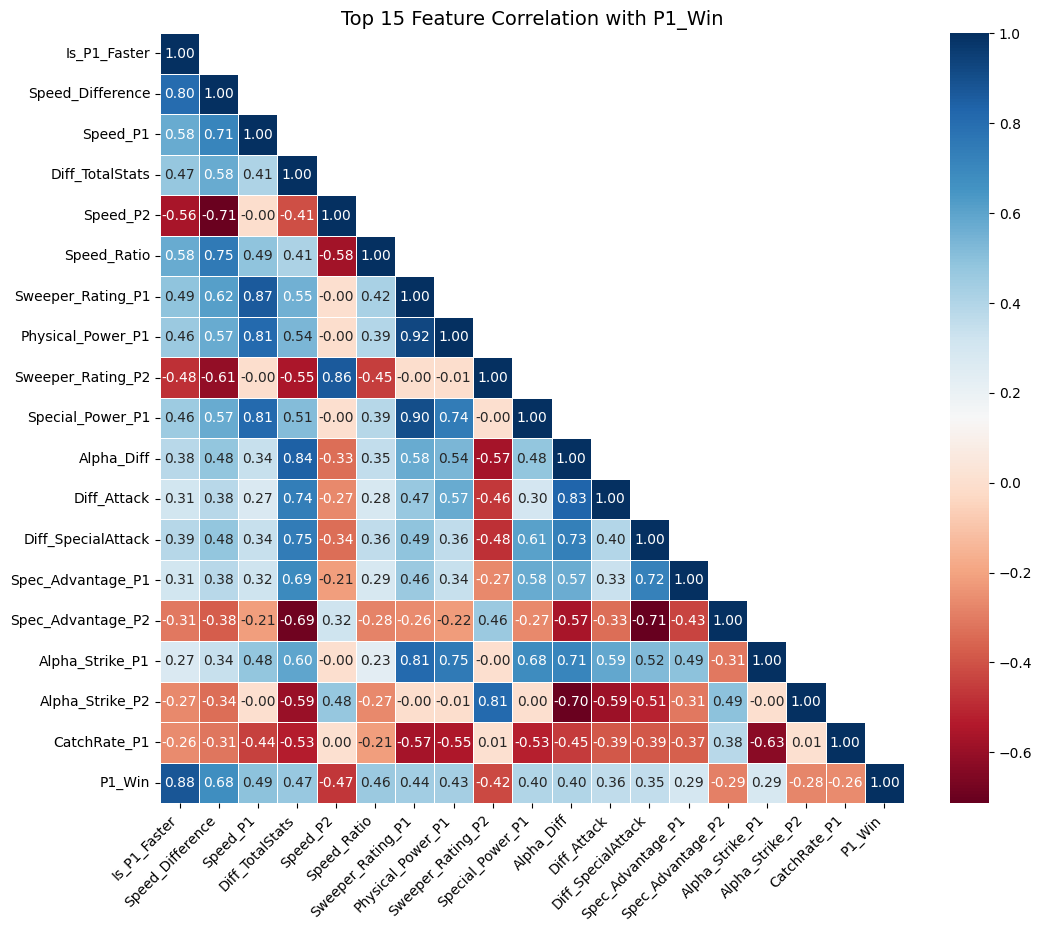

In [91]:
y_train_df = y_train.to_frame(name='P1_Win')
combined_df = pd.concat([X_train.select_dtypes(include=[np.number]), y_train_df], axis=1)

corr_matrix = combined_df.corr()

target_corr = corr_matrix['P1_Win'].sort_values(ascending=False, key=abs)
top_features = target_corr.index[1:19].tolist() 

corr_top = combined_df[top_features + ['P1_Win']].corr()

mask = np.triu(np.ones_like(corr_top, dtype=bool), k=1)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_top,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='RdBu',
    linewidths=.5
)

plt.xticks(rotation=45, ha='right')
plt.title('Top 15 Feature Correlation with P1_Win', fontsize=14)
plt.show()

Nhìn chung không có cặp biến nào tương quan quá mạnh với nhau (>0.9)  
Có hai biến tương quan khá mạnh với P1_Win là P1_Much_Faster và Speed_Difference, đều là hai biến về tốc độ -> tốc độ có thể có ảnh hưởng lớn đến dự đoán pokemon chiến thắng


## **TRAINING MODEL**

Sử dụng RFE để tìm ra các biến quan trọng trong X_train

In [92]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

selector = RFE(estimator=LogisticRegression(solver='liblinear'), n_features_to_select=25, step=1)
selector.fit(X_train_scaled, y_train)

selected_cols = X_train.columns[selector.support_]
print(f"25 biến được chọn: {selected_cols}")


25 biến được chọn: Index(['Speed_P1', 'Type_Dark_P1', 'Type_Dragon_P1', 'Type_Flying_P1',
       'Type_Ghost_P1', 'Alpha_Strike_P1', 'Sweeper_Rating_P1', 'Speed_P2',
       'Type_Dark_P2', 'Type_Ghost_P2', 'Type_Normal_P2', 'Type_Steel_P2',
       'Glass_Cannon_Index_P2', 'Spec_Advantage_P2', 'Alpha_Diff',
       'Physical_Power_P1', 'Special_Power_P1', 'Log_Att_Def_Diff',
       'Speed_Difference', 'Is_P1_Faster', 'P2_Physical_Bulk',
       'P1_Special_Bulk', 'Diff_Hp', 'Diff_SpecialAttack', 'Diff_Attack'],
      dtype='object')


C:\Users\HP\AppData\Local\Temp\ipykernel_14676\364852057.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


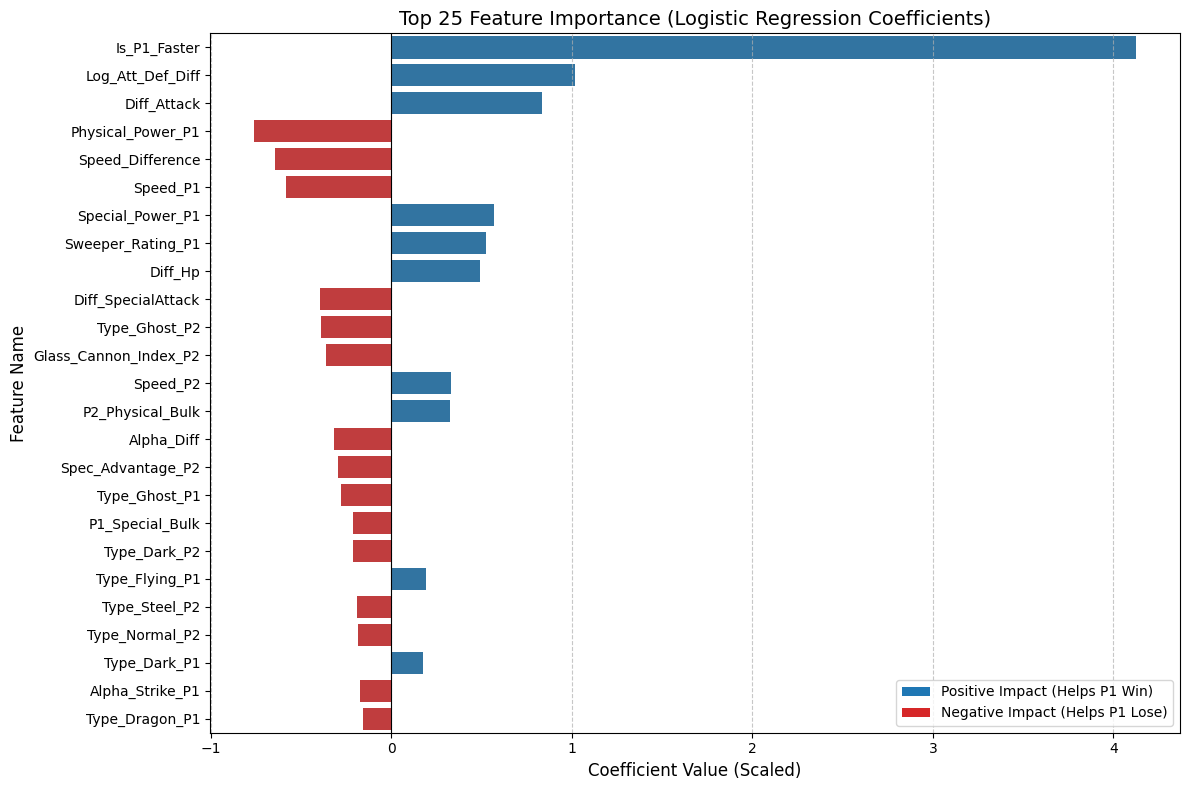

In [93]:
coeffs = selector.estimator_.coef_[0]

importance_df = pd.DataFrame({
    'Feature': selected_cols,
    'Importance': coeffs
})

importance_df['Abs_Importance'] = importance_df['Importance'].abs()
importance_df = importance_df.sort_values(by='Abs_Importance', ascending=False)

plt.figure(figsize=(12, 8))

colors = ['#1f77b4' if x > 0 else '#d62728' for x in importance_df['Importance']]

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    palette=colors
)

plt.title('Top 25 Feature Importance (Logistic Regression Coefficients)', fontsize=14)
plt.xlabel('Coefficient Value (Scaled)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.axvline(0, color='black', linewidth=0.8) 
plt.grid(axis='x', linestyle='--', alpha=0.7)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1f77b4', label='Positive Impact (Helps P1 Win)'),
                   Patch(facecolor='#d62728', label='Negative Impact (Helps P1 Lose)')]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

In [94]:
top_features = selected_cols.tolist()  

poly_log_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(C=1.0, max_iter=2000, solver='liblinear')) 
])

poly_log_model.fit(X_train[top_features], y_train)

train_acc = accuracy_score(y_train, poly_log_model.predict(X_train[top_features]))
test_acc = accuracy_score(y_test, poly_log_model.predict(X_test[top_features]))

print(f"Logistic Regression: Train={train_acc:.4f}, Test={test_acc:.4f}")

Logistic Regression: Train=0.9517, Test=0.9500
